In [1]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Imports successful! ✅")

Imports successful! ✅


In [2]:
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

torch.set_num_threads(4)

PyTorch version: 2.13.0+cpu
CUDA available: False
Running on CPU


In [3]:
DATA_DIR = Path("../data/raw")

TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"

print("Train exists:", TRAIN_PATH.exists())
print("Test exists :", TEST_PATH.exists())

Train exists: True
Test exists : True


In [4]:
train_df = pd.read_csv(
    TRAIN_PATH,
    nrows=20000
)

test_df = pd.read_csv(
    TEST_PATH,
    nrows=5000
)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

Train shape: (20000, 3)
Test shape : (5000, 3)


In [5]:
train_df = train_df.rename(columns={
    "class_index": "label",
    "review_title": "title",
    "review_text": "text"
})

test_df = test_df.rename(columns={
    "class_index": "label",
    "review_title": "title",
    "review_text": "text"
})

print(train_df.columns)

Index(['label', 'title', 'text'], dtype='str')


In [6]:
train_df["label"] = train_df["label"].map({
    1: 0,
    2: 1
})

test_df["label"] = test_df["label"].map({
    1: 0,
    2: 1
})

print(train_df["label"].value_counts())
print(test_df["label"].value_counts())

label
1    10257
0     9743
Name: count, dtype: int64
label
1    2565
0    2435
Name: count, dtype: int64


In [7]:
train_df["text"] = (
    train_df["title"].fillna("") + " " +
    train_df["text"].fillna("")
).str.strip()

test_df["text"] = (
    test_df["title"].fillna("") + " " +
    test_df["text"].fillna("")
).str.strip()

In [8]:
train_df = train_df[["text", "label"]]
test_df = test_df[["text", "label"]]

print(train_df.head())

                                                text  label
0  Stuning even for the non-gamer This sound trac...      1
1  The best soundtrack ever to anything. I'm read...      1
2  Amazing! This soundtrack is my favorite music ...      1
3  Excellent Soundtrack I truly like this soundtr...      1
4  Remember, Pull Your Jaw Off The Floor After He...      1


In [9]:
train_dataset = Dataset.from_pandas(
    train_df,
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    test_df,
    preserve_index=False
)

print(train_dataset)
print(test_dataset)

Dataset({
    features: ['text', 'label'],
    num_rows: 20000
})
Dataset({
    features: ['text', 'label'],
    num_rows: 5000
})


In [10]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

In [11]:
from transformers import AutoTokenizer

MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer loaded successfully! ✅")

Tokenizer loaded successfully! ✅


In [12]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

In [13]:
tokenized_train = train_dataset.map(
    tokenize_function,
    batched=True
)

tokenized_test = test_dataset.map(
    tokenize_function,
    batched=True
)

print(tokenized_train)
print(tokenized_test)

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 20000
})
Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 5000
})


In [14]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

print("DistilBERT loaded! ✅")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT loaded! ✅


In [15]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=-1
    )

    return {
        "accuracy": accuracy_score(labels, predictions),
        "precision": precision_score(labels, predictions),
        "recall": recall_score(labels, predictions),
        "f1": f1_score(labels, predictions)
    }

In [16]:
import accelerate

print("Accelerate version:", accelerate.__version__)

Accelerate version: 1.14.0


In [17]:
import sys

print("Python executable:")
print(sys.executable)

print("\nPython version:")
print(sys.version)

Python executable:
c:\Users\DELL\OneDrive\Desktop\ReviewSense\.venv\Scripts\python.exe

Python version:
3.14.7 (main, Aug 14 2026, 15:39:58) [MSC v.1944 64 bit (AMD64)]


In [18]:
import importlib.util

print("Accelerate installed:",
      importlib.util.find_spec("accelerate"))

Accelerate installed: ModuleSpec(name='accelerate', loader=<_frozen_importlib_external.SourceFileLoader object at 0x0000020F59072ED0>, origin='c:\\Users\\DELL\\OneDrive\\Desktop\\ReviewSense\\.venv\\Lib\\site-packages\\accelerate\\__init__.py', submodule_search_locations=['c:\\Users\\DELL\\OneDrive\\Desktop\\ReviewSense\\.venv\\Lib\\site-packages\\accelerate'])


In [19]:
import sys
import subprocess

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "-U",
    "accelerate>=1.1.0"
])

0

In [20]:
import accelerate

print("Accelerate version:", accelerate.__version__)
print("Loaded from:", accelerate.__file__)

Accelerate version: 1.14.0
Loaded from: c:\Users\DELL\OneDrive\Desktop\ReviewSense\.venv\Lib\site-packages\accelerate\__init__.py


In [21]:
import accelerate
print(accelerate.__version__)

1.14.0


In [22]:
training_args = TrainingArguments(
    output_dir="../models/distilbert",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=1,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=100,
    report_to="none",
    dataloader_num_workers=0
)

print("Training arguments ready! ✅")

Training arguments ready! ✅


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

print("Trainer ready!")

Trainer ready! ✅


In [24]:
trainer.train()

c:\Users\DELL\OneDrive\Desktop\ReviewSense\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.229279,0.230803,0.931800,0.936078,0.930604,0.933333


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2500, training_loss=0.2628407325744629, metrics={'train_runtime': 6646.0654, 'train_samples_per_second': 3.009, 'train_steps_per_second': 0.376, 'total_flos': 662336993280000.0, 'train_loss': 0.2628407325744629, 'epoch': 1.0})

In [25]:
results = trainer.evaluate()

print(f"Accuracy : {results['eval_accuracy']:.4f}")
print(f"Precision: {results['eval_precision']:.4f}")
print(f"Recall   : {results['eval_recall']:.4f}")
print(f"F1 Score : {results['eval_f1']:.4f}")

c:\Users\DELL\OneDrive\Desktop\ReviewSense\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.229279,0.230803,1,0.931800,0.936078,0.930604,0.933333


Accuracy : 0.9318
Precision: 0.9361
Recall   : 0.9306
F1 Score : 0.9333


c:\Users\DELL\OneDrive\Desktop\ReviewSense\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


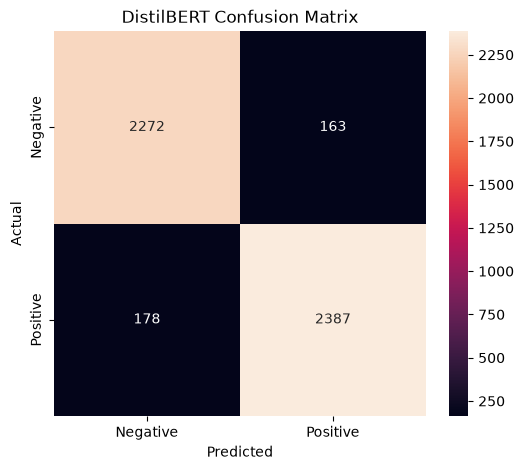

In [26]:
predictions = trainer.predict(tokenized_test)
y_pred = np.argmax(
    predictions.predictions,
    axis=-1
)
y_true = predictions.label_ids
cm = confusion_matrix(
    y_true,
    y_pred
)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("DistilBERT Confusion Matrix")
plt.show()

In [27]:
MODEL_DIR = "../models/distilbert"

trainer.save_model(MODEL_DIR)
tokenizer.save_pretrained(MODEL_DIR)

print("DistilBERT model saved! ✅")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

DistilBERT model saved! ✅
